<a href="https://colab.research.google.com/github/shriyam943/CNN/blob/main/CNN_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow :", tf.__version__)
print("TFDS   :", tfds.__version__)
print("Import done!")

TensorFlow : 2.19.0
TFDS   : 4.9.9
Import done!


In [ ]:

dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)

In [ ]:
dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)

print("Dataset loaded successfully!")
print("Total images :",info.splits['train'].num_examples)
print("Classes :",info.features['label'].names)

Dataset loaded successfully!
Total images : 23262
Classes : ['cat', 'dog']


In [ ]:
TOTAL = info.splits['train'].num_examples
train_size = int(TOTAL * 0.8)
val_size = int(TOTAL * 0.1)

full_dataset = dataset['train']

train_ds = full_dataset.take(train_size)
remaining = full_dataset.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

print("Train images  :",train_size)
print("Validation images :",val_size)
print("Test images :",TOTAL - train_size - val_size)

Train images  : 18609
Validation images : 2326
Test images : 2327


In [ ]:
plt.figure(figsize=(12,6))
class_names = info.features['label'].names

for i, (img, label) in enumerate(train_ds.take(0)):
  plt.subplot(2,4,i+1)
  plt.imshow(image)
  plt.title(class_names[label.numpy()])
  plt.axis('off')

plt.suptitle("Sample Images",fontsize=14)
plt.tight_layout
plt.show()

<Figure size 1200x600 with 0 Axes>

In [ ]:
IMG_SIZE = 64
BATCH_SIZE  = 32

def preprocess(image, label):
  image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
  image = tf.cast(image, tf.float32)/255.0
  return image, label

def augment(image, label):
  image, label = preprocess(image, label)
  image = tf.image.random_flip_left_right(image)
  image = tf.image.random_brightness(image, 0.2)
  image = tf.clip_by_value(image, 0.0, 1.0)
  return image, label

print("Preprocess and augment functions ready!")

Preprocess and augment functions ready!


In [ ]:
from tensorflow.python.ops.batch_ops import batch
train_dataset = (
    train_ds
    .map(augment,num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_ds
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_ds
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Train batches :",len(train_dataset))
print("Validation batches :",len(val_dataset))
print("Test batches :",len(test_dataset))
print("Dataset Prepared!")

Train batches : 582
Validation batches : 73
Test batches : 73
Dataset Prepared!


In [ ]:
cnn = tf.keras.models.Sequential([
     tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu',
                            input_shape=(IMG_SIZE, IMG_SIZE, 3)),
     tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),

     tf.keras.layers.Conv2D(128, kernel_size=3, activation='relu'),
     tf.keras.layers.MaxPool2D(pool_size=2, strides=2),

     tf.keras.layers.Flatten(),

     tf.keras.layers.Dense(128, activation='relu'),

     tf.keras.layers.Dropout(0.5),

     tf.keras.layers.Dense(1, activation='sigmoid')
])
print("CNN Model built successfully!")

CNN Model built successfully!


In [ ]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,249,409 (12.40 MB)

 Trainable params: 3,249,409 (12.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = cnn.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 67ms/step - accuracy: 0.6554 - loss: 0.6179 - val_accuracy: 0.7476 - val_loss: 0.5105
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.7539 - loss: 0.5048 - val_accuracy: 0.7704 - val_loss: 0.4826
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - accuracy: 0.7881 - loss: 0.4555 - val_accuracy: 0.8009 - val_loss: 0.4294
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.8070 - loss: 0.4194 - val_accuracy: 0.8087 - val_loss: 0.4106
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - accuracy: 0.8254 - loss: 0.3919 - val_accuracy: 0.8220 - val_loss: 0.3983
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.8460 - loss: 0.3569 - val_accuracy: 0.8164 - val_loss: 0.3969
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - accuracy: 0.8556 - loss: 0.3328 - val_accuracy: 0.8130 - val_loss: 0.4103
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - accuracy: 0.8633 - loss: 0.3095 - 

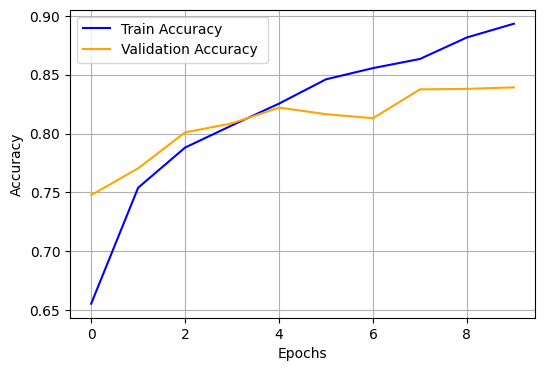

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy ', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy ', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


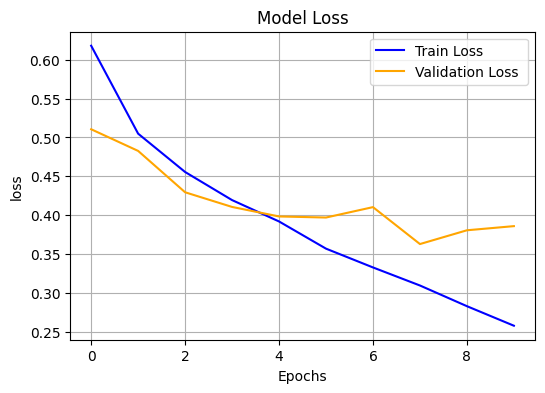

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss ', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss ', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
test_loss, test_accuracy = cnn.evaluate(test_dataset)
print("\n====== Test Result ========")
print(f"Test Loss :     :{test_loss:.4f}")
print(f"Test Accuracy :{test_accuracy * 100:.2f}%")
print("============================")

73/73 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.8341 - loss: 0.4139

====== Test Result ========
Test Loss :     :0.4139
Test Accuracy :83.41%


In [ ]:
cnn.save('cat_dog_model.h5')
print("Model saved as cat_dog_model.h5")

Model saved as cat_dog_model.h5


Please upload a cat or dog image....


Saving cute-little-kitten.jpeg to cute-little-kitten (5).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Raw prediction: 0.91682625
Prediction: Cat
Confidence: 91.68%


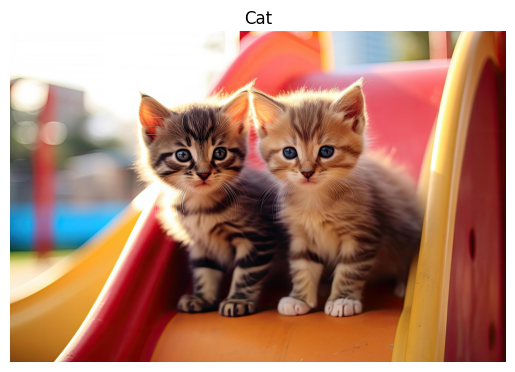

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

print("Please upload a cat or dog image....")
uploaded = files.upload()

img_path = list(uploaded.keys())[0]
img = image.load_img(img_path, target_size=(64, 64))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

prediction = cnn.predict(img_array)
confidence = prediction[0][0]

print("\n====================")
print("Raw prediction:", confidence)

if confidence > 0.5:
    label = "Cat"
else:
    label = "Dog"

print(f"Prediction: {label}")
print(f"Confidence: {conf_text}")
print("====================")

img_display = image.load_img(img_path)
plt.imshow(img_display)
plt.title(label)
plt.axis('off')
plt.show()


In [ ]:
prediction = cnn.predict(img_array)
confidence = prediction[0][0]

print("\n====================")
print("Raw prediction:", confidence)

# Distance from 0.5 = confidence strength
distance = abs(confidence - 0.5)

if distance < 0.2:
    label = "Other Animal"
    conf_text = f"{distance * 200:.2f}% (Uncertain)"
elif confidence > 0.5:
    label = "Dog"
    conf_text = f"{confidence * 100:.2f}%"
else:
    label = "Cat"
    conf_text = f"{(1 - confidence) * 100:.2f}%"

print(f"Prediction: {label}")
print(f"Confidence: {conf_text}")
print("====================")
img_display = image.load_img(img_path)
plt.imshow(img_display) plt.title(label) plt.axis('off') plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Raw prediction: 0.9447422
Prediction: Dog
Confidence: 94.47%
